In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

root = Path("results")
csv_files = list(root.glob("*/periodic_image_distance_*/pi_dist_summary_*.csv"))
print(f"Found {len(csv_files)} CSV files.")

dfs = []

for f in csv_files:
    pdbid = f.parts[-3]
    df = pd.read_csv(f)
    df["pdb"] = pdbid
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

display(df_all.head())
print(df_all.columns)
print(df_all["pdb"].unique())
print(df_all.shape)

Found 94 CSV files.


,pdb,replica,xtc,xvg,n_frames,min_dist_nm,max_dist_nm,mean_dist_nm,median_dist_nm,p01_dist_nm,p05_dist_nm,p95_dist_nm,p99_dist_nm,status
0,5s2e,0,cleaned_5s2e_0.xtc,pi_dist_5s2e_0.xvg,10001,1.402,2.296,1.920370,1.932,1.589,1.692,2.109,2.163,ok
1,5s2e,1,cleaned_5s2e_1.xtc,pi_dist_5s2e_1.xvg,10001,1.243,2.291,1.898573,1.919,1.487,1.619,2.108,2.164,ok
2,5s2e,2,cleaned_5s2e_2.xtc,pi_dist_5s2e_2.xvg,10001,1.000,2.250,1.886851,1.912,1.337,1.571,2.103,2.166,ok
3,5s2e,3,cleaned_5s2e_3.xtc,pi_dist_5s2e_3.xvg,10001,1.122,2.274,1.936945,1.948,1.620,1.725,2.115,2.165,ok
4,5s2e,4,cleaned_5s2e_4.xtc,pi_dist_5s2e_4.xvg,10001,1.012,2.259,1.911506,1.932,1.428,1.638,2.111,2.164,ok


Index(['pdb', 'replica', 'xtc', 'xvg', 'n_frames', 'min_dist_nm',
       'max_dist_nm', 'mean_dist_nm', 'median_dist_nm', 'p01_dist_nm',
       'p05_dist_nm', 'p95_dist_nm', 'p99_dist_nm', 'status'],
      dtype='object')
['5s2e' '1ncx' '2bem' '7p8f' '1l0c' '1xyh' '6ghh' '5s3v' '7gzz' '4ykw'
 '5kch' '1vc1' '5b08' '7due' '8okr' '3a8c' '6el5' '8den' '7f2b' '7y05'
 '1hia' '4dg4' '2znt' '8az4' '2gg7' '3m3x' '4rfz' '4ded' '7nns' '6bsk'
 '2aps' '8bpt' '5fns' '2p16' '2c2l' '1yxv' '1ptz' '7d2d' '1m2r' '8c8s'
 '5osu' '7ons' '5fp8' '4gub' '5c1w' '3giv' '4a39' '8roo' '3t00' '2hla'
 '2q11' '8erx' '8gs9' '4j0j' '6eh8' '1ggp' '7xed' '2qhr' '7n6h' '2mcp'
 '5zr8' '2vff' '1fof' '1a7u' '3b9c' '1yvx' '1zty' '3d6d' '6qpm' '8bdp'
 '7wpi' '4dme' '3nxb' '5j7e' '1wy9' '3ef4' '7lak' '3era' '1onl' '4hoi'
 '7n3z' '1nbq' '1kap' '4azu' '3h90' '1dxx' '4xqa' '5rsi' '1p27' '7bru'
 '2vfd' '4k0y' '6typ']
(938, 14)


In [68]:
# sort for min dsitance
cutoff = 1.2 #nm

bad = df_all["too_small"] = df_all["min_dist_nm"] < cutoff
safe = df_all["safe"] = df_all["min_dist_nm"] >= cutoff + 0.1
marginal = df_all["marginal"] = (df_all["min_dist_nm"] > cutoff) & (df_all["min_dist_nm"] < cutoff + 0.1) 

flagged = df_all[~df_all["safe"]]

print(f"Flagged {flagged.shape[0]} out of {df_all.shape[0]} structures ({flagged.shape[0]/df_all.shape[0]*100:.2f}%)")
display(flagged[["pdb", "min_dist_nm", "xtc"]])

Flagged 798 out of 938 structures (85.07%)


,pdb,min_dist_nm,xtc
1,5s2e,1.243,cleaned_5s2e_1.xtc
2,5s2e,1.000,cleaned_5s2e_2.xtc
3,5s2e,1.122,cleaned_5s2e_3.xtc
4,5s2e,1.012,cleaned_5s2e_4.xtc
5,5s2e,1.117,cleaned_5s2e_5.xtc
...,...,...,...
933,6typ,1.125,cleaned_6typ_5.xtc
934,6typ,1.094,cleaned_6typ_6.xtc
935,6typ,1.115,cleaned_6typ_7.xtc
936,6typ,1.086,cleaned_6typ_8.xtc


In [60]:
#filter for PDB only

flagged_pdbs = flagged["pdb"].unique()
print(f"Flagged {len(flagged_pdbs)} unique PDBs.")
print(flagged_pdbs)

Flagged 90 unique PDBs.
['5s2e' '1ncx' '2bem' '7p8f' '1l0c' '1xyh' '6ghh' '5s3v' '7gzz' '4ykw'
 '5kch' '1vc1' '5b08' '7due' '8okr' '3a8c' '6el5' '8den' '7f2b' '7y05'
 '1hia' '4dg4' '2znt' '8az4' '2gg7' '3m3x' '4rfz' '4ded' '7nns' '6bsk'
 '2aps' '8bpt' '5fns' '2p16' '2c2l' '1yxv' '1ptz' '7d2d' '1m2r' '8c8s'
 '5osu' '7ons' '5fp8' '4gub' '5c1w' '3giv' '4a39' '8roo' '3t00' '2hla'
 '2q11' '8erx' '4j0j' '6eh8' '1ggp' '7xed' '2qhr' '2mcp' '5zr8' '2vff'
 '1fof' '1a7u' '3b9c' '1yvx' '1zty' '3d6d' '6qpm' '8bdp' '7wpi' '4dme'
 '3nxb' '5j7e' '1wy9' '3ef4' '3era' '1onl' '4hoi' '7n3z' '1nbq' '1kap'
 '4azu' '3h90' '1dxx' '4xqa' '5rsi' '1p27' '7bru' '2vfd' '4k0y' '6typ']


In [72]:
#group by pdb and get the min for each pdb

grouped = df_all.groupby("pdb").agg({"min_dist_nm": "min", "too_small": "any", "safe": "any", "marginal": "any"}).reset_index()
display(grouped.head())
display(grouped["pdb"].value_counts())


,pdb,min_dist_nm,too_small,safe,marginal
0,1a7u,0.237,True,False,True
1,1dxx,0.296,True,False,False
2,1fof,1.109,True,True,True
3,1ggp,1.122,True,True,True
4,1hia,1.077,True,True,True


pdb
1a7u    1
1dxx    1
1fof    1
1ggp    1
1hia    1
       ..
8den    1
8erx    1
8gs9    1
8okr    1
8roo    1
Name: count, Length: 93, dtype: int64

In [62]:
#take all options below a set value

filtered = df_all[df_all["min_dist_nm"] < 0.4]
print(f"Found {filtered.shape[0]} options with min distance < 0.4 nm.")
display(filtered[["pdb", "min_dist_nm", "xtc"]])
if not (root / "000analysis").exists():
    (root / "000analysis").mkdir(parents=True)
filtered.to_csv(root / "000analysis" / "pi_dist_filtered.csv", index=False)

Found 90 options with min distance < 0.4 nm.


,pdb,min_dist_nm,xtc
57,1xyh,0.332,cleaned_1xyh_7.xtc
130,7due,0.256,cleaned_7due_0.xtc
136,7due,0.354,cleaned_7due_6.xtc
140,8okr,0.251,cleaned_8okr_0.xtc
144,8okr,0.296,cleaned_8okr_4.xtc
...,...,...,...
852,3h90,0.252,cleaned_3h90_4.xtc
853,3h90,0.381,cleaned_3h90_5.xtc
856,3h90,0.299,cleaned_3h90_8.xtc
862,1dxx,0.296,cleaned_1dxx_4.xtc


In [ ]:
# group by pdbid, get the min value of mindist per each pdbid
filtered = filtered.sort_values("min_dist_nm")
grouped_filtered = filtered.groupby("pdb").agg({"min_dist_nm": "min", "xtc": "first"}).reset_index()
display(grouped_filtered.head())
print(grouped_filtered.shape)

#order them in ascending order of min_dist_nm and save to csv
date_str = datetime.now().strftime("%Y%m%d")
grouped_filtered = grouped_filtered.sort_values("min_dist_nm")
grouped_filtered.to_csv(root / "000analysis" / f"pi_dist_filtered_grouped_{date_str}.csv", index=False)
print(number_of_pdbs := grouped_filtered.shape[0])



,pdb,min_dist_nm,xtc
0,1a7u,0.237,cleaned_1a7u_7.xtc
1,1dxx,0.296,cleaned_1dxx_4.xtc
2,1kap,0.232,cleaned_1kap_2.xtc
3,1nbq,0.112,cleaned_1nbq_3.xtc
4,1xyh,0.332,cleaned_1xyh_7.xtc


(20, 3)
20


In [86]:
# Cross check if they are monomeric or multimeric in the original PDB file
# and keep min_dist_nm

pi_df = pd.read_csv(f"results/000analysis/pi_dist_filtered_grouped_{date_str}.csv")
st_df = pd.read_csv("results/000analysis/pdb_monomer_multimer_status.csv")

# Check columns
print(pi_df.columns.tolist())

# Standardise PDB IDs
pi_df["pdb"] = (
    pi_df["pdb"]
    .astype(str)
    .str.strip()
    .str.lower()
)

st_df["PDB"] = (
    st_df["PDB"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Merge
pi_checked = pi_df.merge(
    st_df[["PDB", "State", "Chains"]],
    left_on="pdb",
    right_on="PDB",
    how="left"
)

# Keep useful columns near each other
cols_first = ["pdb", "min_dist_nm", "State", "Chains"]

other_cols = [
    col for col in pi_checked.columns
    if col not in cols_first
]

pi_checked = pi_checked[cols_first + other_cols]

pi_checked.head()
display(pi_checked.shape)

['pdb', 'min_dist_nm', 'xtc']


(20, 6)

In [79]:
pi_checked.to_csv(
    root / "000analysis" / f"pi_dist_chainstate_{date_str}.csv",
    index=False
)

pi_checked[["pdb", "min_dist_nm", "State", "Chains"]].head()

pi_checked.groupby("State")["min_dist_nm"].describe()

,count,mean,std,min,25%,50%,75%,max
State,,,,,,,,
Monomer,4.0,0.357000,0.029200,0.332,0.34175,0.3485,0.36375,0.399
Multimer (10 chains),1.0,0.261000,NaN,0.261,0.26100,0.2610,0.26100,0.261
Multimer (2 chains),7.0,0.233857,0.056461,0.112,0.23450,0.2500,0.26150,0.283
Multimer (24 chains),1.0,0.250000,NaN,0.250,0.25000,0.2500,0.25000,0.250
Multimer (3 chains),1.0,0.282000,NaN,0.282,0.28200,0.2820,0.28200,0.282
Multimer (4 chains),5.0,0.281000,0.046583,0.235,0.25200,0.2680,0.29600,0.354
Multimer (8 chains),1.0,0.239000,NaN,0.239,0.23900,0.2390,0.23900,0.239


<Axes: title={'center': 'min_dist_nm'}, xlabel='State'>

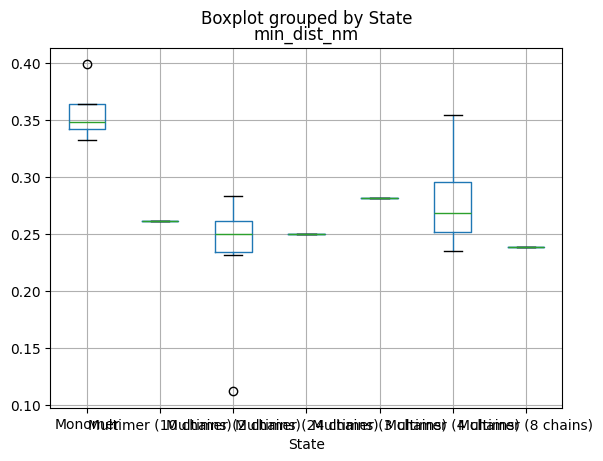

In [82]:
# Keep the row with the minimum min_dist_nm for each PDB

pi_min = (
    pi_checked.loc[
        pi_checked.groupby("pdb")["min_dist_nm"].idxmin()
    ]
    .reset_index(drop=True)
)

pi_min.head()

pi_min.to_csv(
    root / "000analysis" / f"pi_dist_chainstate_minonly_{date_str}.csv",
    index=False

)

pi_min.groupby("State")["min_dist_nm"].describe()
pi_min.boxplot(column="min_dist_nm", by="State")

In [85]:
#cross check if they are monomeric or multimeric in the original PDB file

# Load pi-dist results
pi_df = pi_read = pd.read_csv(root / "000analysis" / f"pi_dist_chainstate_minonly_{date_str}.csv",)
st_df = pd.read_csv(root / "000analysis" / "pdb_monomer_multimer_status.csv")

pi_df.head()

# Standardise PDB IDs
pi_df["pdb"] = (
    pi_df["pdb"]
    .astype(str)
    .str.strip()
    .str.lower()
)

st_df["PDB"] = (
    st_df["PDB"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Merge
pi_checked = pi_df.merge(
    st_df[["PDB", "State", "Chains"]],
    left_on="pdb",
    right_on="PDB",
    how="left"
)

cols_to_keep = ["pdb", "min_dist_nm", "xtc", "State", "Chains"]

other_cols = [
    col for col in pi_checked.columns if col not in cols_to_keep
]
pi_checked = pi_checked[cols_to_keep + other_cols]

pi_checked.head()
pi_checked.to_csv(root / "000analysis" / f"pi_dist_chainstate_{date_str}.csv", index=False)

KeyError: "['State', 'Chains'] not in index"